# Bloque II — Regresión con dataset Iris

**Duración estimada:** 3 horas  
**Dataset:** `Iris.csv`

## Objetivo de aprendizaje

El alumnado aprenderá a construir modelos de regresión para predecir una variable numérica continua, comparar distintos algoritmos y justificar la elección del modelo mediante métricas.

En este caso, utilizaremos el famoso dataset **Iris** para predecir la variable `PetalLengthCm` (longitud del pétalo) a partir del resto de las características florales.

## Agenda de 3 horas

| Tiempo | Actividad |
|---:|---|
| 0:00–0:25 | Qué es un problema de regresión |
| 0:25–0:55 | Preparación del dataset Iris |
| 0:55–1:25 | Regresión lineal simple y múltiple |
| 1:25–1:35 | Pausa |
| 1:35–2:05 | Ridge, Lasso y Random Forest |
| 2:05–2:35 | Métricas y comparación |
| 2:35–3:00 | Caso práctico |

In [1]:
# Configuración común
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Estilo para los gráficos
plt.style.use('default')
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Carga y exploración del dataset Iris

El dataset Iris es uno de los más conocidos en aprendizaje automático. Contiene 150 muestras de flores Iris con las siguientes variables:

- `SepalLengthCm`: Longitud del sépalo (cm)
- `SepalWidthCm`: Ancho del sépalo (cm)
- `PetalLengthCm`: Longitud del pétalo (cm) — **nuestra variable objetivo**
- `PetalWidthCm`: Ancho del pétalo (cm)
- `Species`: Especie de la flor (Iris-setosa, Iris-versicolor, Iris-virginica)

In [3]:
df = pd.read_csv("Iris.csv")
df.head(10)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.100,3.500,1.400,0.200,Iris-setosa
1,2,4.900,3.000,1.400,0.200,Iris-setosa
2,3,4.700,3.200,1.300,0.200,Iris-setosa
3,4,4.600,3.100,1.500,0.200,Iris-setosa
4,5,5.000,3.600,1.400,0.200,Iris-setosa
5,6,5.400,3.900,1.700,0.400,Iris-setosa
6,7,4.600,3.400,1.400,0.300,Iris-setosa
7,8,5.000,3.400,1.500,0.200,Iris-setosa
8,9,4.400,2.900,1.400,0.200,Iris-setosa
9,10,4.900,3.100,1.500,0.100,Iris-setosa


In [4]:
# Exploración básica
print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores nulos:")
print(df.isnull().sum())
print("\nEspecies únicas:")
print(df["Species"].unique())

Shape: (150, 6)

Columnas: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Tipos de datos:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object

Valores nulos:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Especies únicas:
<StringArray>
['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
Length: 3, dtype: str


In [5]:
# Estadísticas descriptivas
print("Estadísticas descriptivas de las variables numéricas:")
df.describe()

Estadísticas descriptivas de las variables numéricas:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000,150.000,150.000,150.000,150.000
mean,75.500,5.843,3.054,3.759,1.199
std,43.445,0.828,0.434,1.764,0.763
min,1.000,4.300,2.000,1.000,0.100
25%,38.250,5.100,2.800,1.600,0.300
50%,75.500,5.800,3.000,4.350,1.300
75%,112.750,6.400,3.300,5.100,1.800
max,150.000,7.900,4.400,6.900,2.500


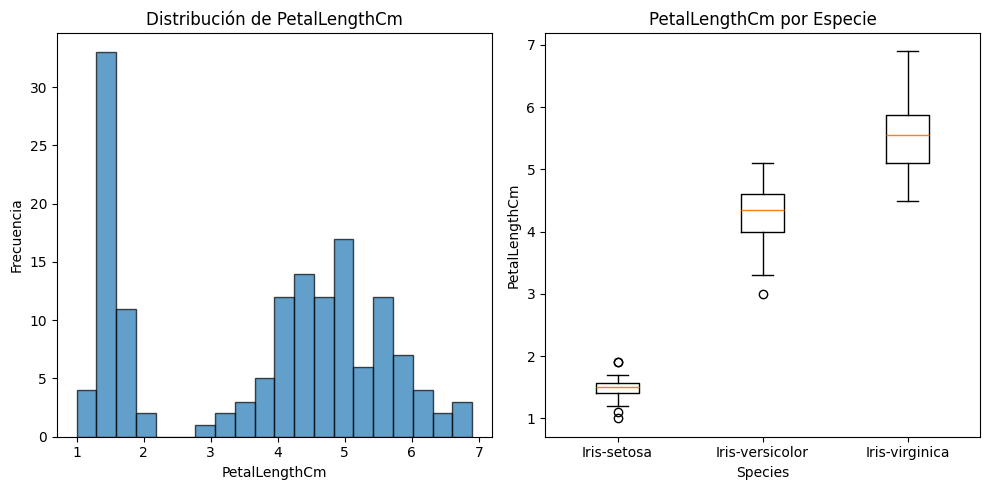

In [6]:
# Visualización de la distribución de la variable objetivo
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(df["PetalLengthCm"], bins=20, edgecolor="black", alpha=0.7)
plt.xlabel("PetalLengthCm")
plt.ylabel("Frecuencia")
plt.title("Distribución de PetalLengthCm")

plt.subplot(1, 2, 2)
# Boxplot usando matplotlib (sin seaborn)
species_data = [df[df["Species"] == sp]["PetalLengthCm"].values for sp in df["Species"].unique()]
plt.boxplot(species_data, labels=df["Species"].unique())
plt.xlabel("Species")
plt.ylabel("PetalLengthCm")
plt.title("PetalLengthCm por Especie")
plt.tight_layout()
plt.show()

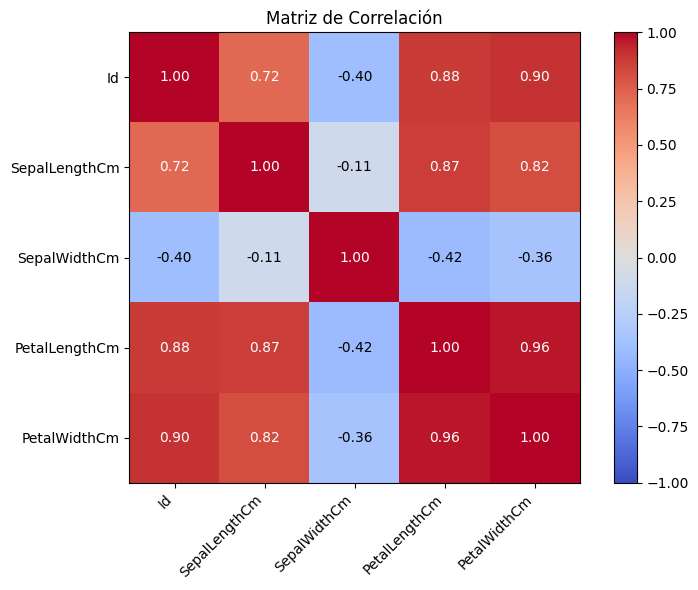


Correlación con PetalLengthCm:
PetalLengthCm    1.000
PetalWidthCm     0.963
Id               0.883
SepalLengthCm    0.872
SepalWidthCm    -0.421
Name: PetalLengthCm, dtype: float64


In [7]:
# Matriz de correlación
plt.figure(figsize=(8, 6))
corr = df.select_dtypes(include=[np.number]).corr()

# Usar matplotlib para el heatmap (sin seaborn)
import matplotlib.cm as cm

im = plt.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)

# Etiquetas
labels = corr.columns.tolist()
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.yticks(range(len(labels)), labels)

# Valores en cada celda
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", 
                ha='center', va='center', color='white' if abs(corr.iloc[i, j]) > 0.5 else 'black')

plt.title("Matriz de Correlación")
plt.tight_layout()
plt.show()

# La correlación entre PetalLengthCm y las otras variables numéricas
print("\nCorrelación con PetalLengthCm:")
print(corr["PetalLengthCm"].sort_values(ascending=False))

## 2. Definición de X e y

En este problema de regresión:

- `X` contiene las variables predictoras: `SepalLengthCm`, `SepalWidthCm`, `PetalWidthCm` y `Species`.
- `y` contiene la variable numérica que queremos predecir: `PetalLengthCm`.

La variable `Species` es categórica, por lo que usaremos One-Hot Encoding para convertirla en variables numéricas.

In [8]:
target = "PetalLengthCm"

# Variables numéricas
features_num = ["SepalLengthCm", "SepalWidthCm", "PetalWidthCm"]

# Variable categórica
features_cat = ["Species"]

X = df[features_num + features_cat]
y = df[target]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
X.head()

Forma de X: (150, 4)
Forma de y: (150,)


,SepalLengthCm,SepalWidthCm,PetalWidthCm,Species
0,5.100,3.500,0.200,Iris-setosa
1,4.900,3.000,0.200,Iris-setosa
2,4.700,3.200,0.200,Iris-setosa
3,4.600,3.100,0.200,Iris-setosa
4,5.000,3.600,0.200,Iris-setosa


## 3. División train/test

La evaluación debe hacerse con datos no usados durante el entrenamiento. Usamos un 80 % para entrenamiento y un 20 % para prueba.

Fijamos `random_state=42` para que los resultados sean reproducibles.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (120, 4)
X_test: (30, 4)
y_train: (120,)
y_test: (30,)


## 4. Preprocesamiento

Los modelos necesitan datos numéricos. Las variables categóricas se codifican con One-Hot Encoding y las numéricas se escalan cuando procede.

Usaremos `Pipeline` para evitar fugas de información y mantener el flujo reproducible.

**Nota:** Para este dataset no hay valores nulos, pero incluimos el imputador por buena práctica.

In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer, features_cat)
    ]
)

## 5. Función de evaluación

Centralizamos las métricas para comparar todos los modelos con el mismo criterio.

- **MAE** (Mean Absolute Error): error absoluto medio. Indica el error promedio en las mismas unidades que la variable objetivo (cm).
- **RMSE** (Root Mean Squared Error): raíz del error cuadrático medio. Penaliza errores grandes.
- **R²**: proporción de variabilidad explicada. Un valor cercano a 1 indica un buen ajuste.

In [11]:
def evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test):
    """Entrena el modelo y evalúa con métricas estándar."""
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    return {
        "modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }, pred

## 6. Regresión Lineal

La regresión lineal es interpretable y sirve como primera referencia. Aunque no siempre será el modelo más preciso, es muy útil para establecer una línea base.

Fórmula: `PetalLengthCm = β₀ + β₁·SepalLengthCm + β₂·SepalWidthCm + β₃·PetalWidthCm + β₄·Species_encoded + ε`

In [12]:
modelo_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

res_lr, pred_lr = evaluar_modelo("Linear Regression", modelo_lr, X_train, X_test, y_train, y_test)
res_lr

{'modelo': 'Linear Regression',
 'MAE': 0.22705547907892018,
 'RMSE': np.float64(0.29596564061155195),
 'R2': 0.9732727291779208}

In [13]:
# Visualizar coeficientes de la regresión lineal (solo variables numéricas)
# Obtener nombres de características después del preprocesamiento
preprocessor_fit = preprocessor.fit(X_train)
feature_names = (features_num + 
                 preprocessor_fit.named_transformers_["cat"].named_steps["onehot"]
                 .get_feature_names_out(features_cat).tolist())

# Obtener coeficientes
lr_model = modelo_lr.named_steps["model"]
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": lr_model.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print("Coeficientes del modelo de Regresión Lineal:")
print(f"Intercepto: {lr_model.intercept_:.4f}")
coef_df

Coeficientes del modelo de Regresión Lineal:
Intercepto: 2.5965


,feature,coefficient
4,Species_Iris-virginica,1.960
3,Species_Iris-versicolor,1.446
0,SepalLengthCm,0.482
2,PetalWidthCm,0.482
1,SepalWidthCm,-0.069


## 7. Ridge y Lasso

Ridge y Lasso introducen regularización (penalización sobre los coeficientes). Esto reduce el riesgo de sobreajuste y ayuda a controlar la complejidad del modelo.

- **Ridge** (L2): penaliza la suma de los cuadrados de los coeficientes.
- **Lasso** (L1): penaliza la suma del valor absoluto de los coeficientes. Puede llevar coeficientes a cero (selección de variables).

In [14]:
modelo_ridge = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

modelo_lasso = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.05, max_iter=10000))
])

res_ridge, pred_ridge = evaluar_modelo("Ridge", modelo_ridge, X_train, X_test, y_train, y_test)
res_lasso, pred_lasso = evaluar_modelo("Lasso", modelo_lasso, X_train, X_test, y_train, y_test)

print("Ridge:", res_ridge)
print("Lasso:", res_lasso)

Ridge: {'modelo': 'Ridge', 'MAE': 0.2305661143776248, 'RMSE': np.float64(0.31557669456497217), 'R2': 0.9696134167995192}
Lasso: {'modelo': 'Lasso', 'MAE': 0.2582333673268706, 'RMSE': np.float64(0.36108759416215186), 'R2': 0.9602170340236876}


In [15]:
# Comparar coeficientes: Ridge vs Lasso
ridge_model = modelo_ridge.named_steps["model"]
lasso_model = modelo_lasso.named_steps["model"]

coef_comparison = pd.DataFrame({
    "feature": feature_names,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_
})
print("Comparación de coeficientes (Ridge vs Lasso):")
coef_comparison

Comparación de coeficientes (Ridge vs Lasso):


,feature,Ridge,Lasso
0,SepalLengthCm,0.547,0.541
1,SepalWidthCm,-0.188,-0.237
2,PetalWidthCm,0.824,1.110
3,Species_Iris-versicolor,0.648,0.000
4,Species_Iris-virginica,0.850,0.000


## 8. Random Forest Regressor

Random Forest es un modelo de ensemble basado en árboles de decisión. Permite capturar relaciones no lineales e interacciones entre variables. Suele mejorar el rendimiento, aunque a costa de menor interpretabilidad.

Ventajas para este dataset:
- No requiere que las variables sean linealmente relacionadas.
- Maneja bien la combinación de variables numéricas y categóricas.
- Nos permite ver la importancia de cada característica.

In [16]:
modelo_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=None
    ))
])

res_rf, pred_rf = evaluar_modelo("Random Forest", modelo_rf, X_train, X_test, y_train, y_test)
res_rf

{'modelo': 'Random Forest',
 'MAE': 0.2652081746031759,
 'RMSE': np.float64(0.3097190083181345),
 'R2': 0.9707310095427553}

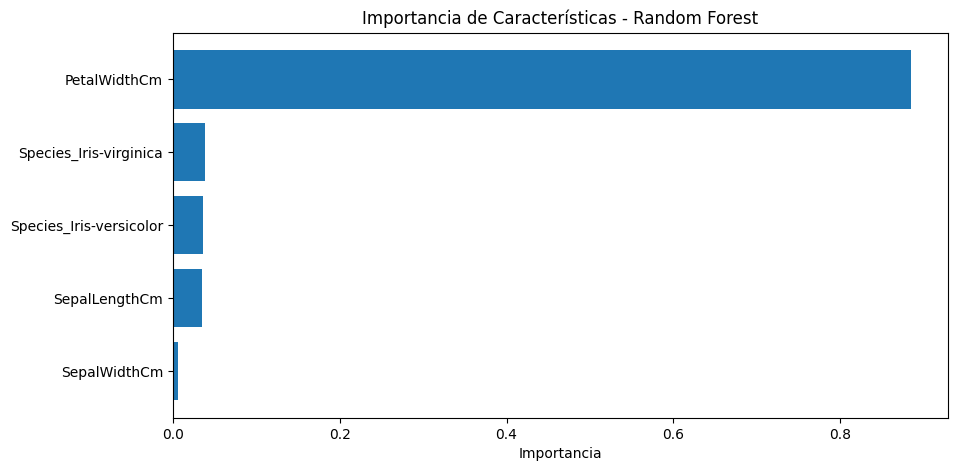

Importancia de características:


,feature,importance
2,PetalWidthCm,0.885
4,Species_Iris-virginica,0.038
3,Species_Iris-versicolor,0.035
0,SepalLengthCm,0.035
1,SepalWidthCm,0.006


In [17]:
# Importancia de características en Random Forest
rf_model = modelo_rf.named_steps["model"]
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.xlabel("Importancia")
plt.title("Importancia de Características - Random Forest")
plt.gca().invert_yaxis()
plt.show()

print("Importancia de características:")
importance_df

## 9. Comparación de modelos

La decisión final debe combinar precisión, interpretabilidad, estabilidad y facilidad de despliegue.

El modelo con menor RMSE y mayor R² será el que mejor prediga la longitud del pétalo.

In [18]:
resultados = pd.DataFrame([res_lr, res_ridge, res_lasso, res_rf])
resultados = resultados.sort_values("RMSE")
print("Comparación de modelos (ordenado por RMSE):")
resultados

Comparación de modelos (ordenado por RMSE):


,modelo,MAE,RMSE,R2
0,Linear Regression,0.227,0.296,0.973
3,Random Forest,0.265,0.310,0.971
1,Ridge,0.231,0.316,0.970
2,Lasso,0.258,0.361,0.960


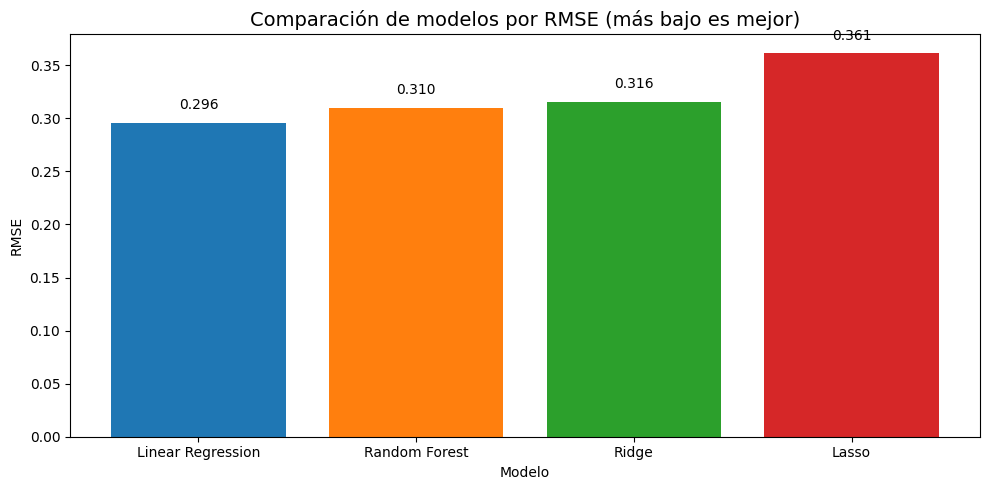

In [19]:
# Gráfico de barras comparando RMSE
plt.figure(figsize=(10, 5))
bars = plt.bar(resultados["modelo"], resultados["RMSE"], color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
plt.title("Comparación de modelos por RMSE (más bajo es mejor)", fontsize=14)
plt.ylabel("RMSE")
plt.xlabel("Modelo")

# Añadir etiquetas con valores
for bar, rmse in zip(bars, resultados["RMSE"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f"{rmse:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

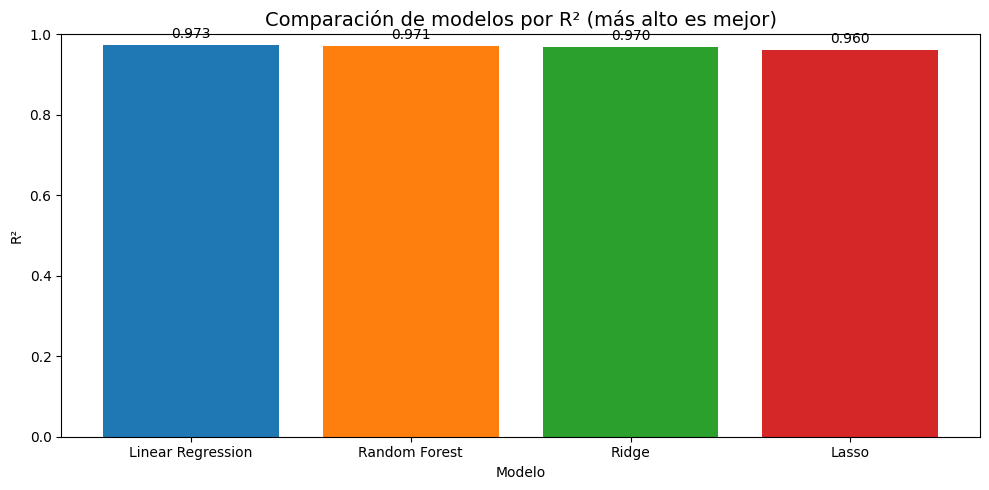

In [20]:
# Gráfico comparando R²
plt.figure(figsize=(10, 5))
bars = plt.bar(resultados["modelo"], resultados["R2"], color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
plt.title("Comparación de modelos por R² (más alto es mejor)", fontsize=14)
plt.ylabel("R²")
plt.xlabel("Modelo")
plt.ylim([0, 1])

# Añadir etiquetas con valores
for bar, r2 in zip(bars, resultados["R2"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f"{r2:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 10. Visualización: Real vs Predicho

Este gráfico permite observar si el modelo tiende a infraestimar o sobreestimar. Los puntos cerca de la línea diagonal indican predicciones precisas.

In [21]:
# Usamos el mejor modelo según RMSE
mejor_modelo_nombre = resultados.iloc[0]["modelo"]
print(f"Mejor modelo según RMSE: {mejor_modelo_nombre}")

if mejor_modelo_nombre == "Linear Regression":
    mejor_pred = pred_lr
    mejor_modelo = modelo_lr
elif mejor_modelo_nombre == "Ridge":
    mejor_pred = pred_ridge
    mejor_modelo = modelo_ridge
elif mejor_modelo_nombre == "Lasso":
    mejor_pred = pred_lasso
    mejor_modelo = modelo_lasso
else:
    mejor_pred = pred_rf
    mejor_modelo = modelo_rf

Mejor modelo según RMSE: Linear Regression


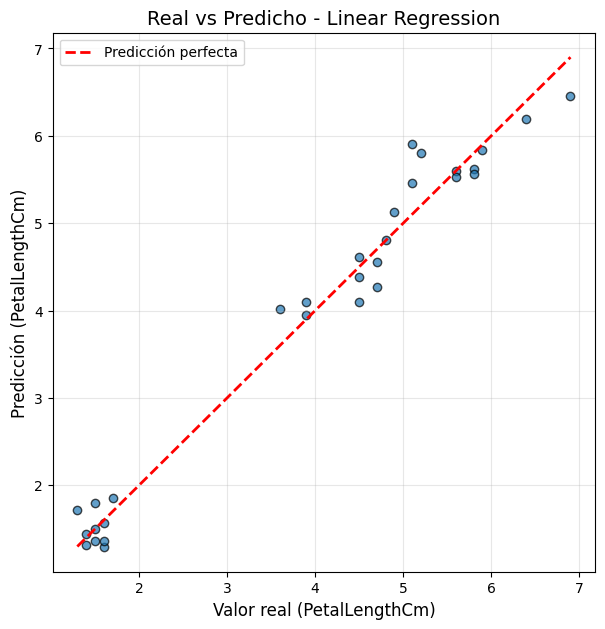

Error medio (MAE): 0.2271
RMSE: 0.2960
R²: 0.9733


In [22]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, mejor_pred, alpha=0.7, edgecolors="black")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label="Predicción perfecta")
plt.xlabel("Valor real (PetalLengthCm)", fontsize=12)
plt.ylabel("Predicción (PetalLengthCm)", fontsize=12)
plt.title(f"Real vs Predicho - {mejor_modelo_nombre}", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calcular residuos
residuos = y_test - mejor_pred
print(f"Error medio (MAE): {mean_absolute_error(y_test, mejor_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, mejor_pred)):.4f}")
print(f"R²: {r2_score(y_test, mejor_pred):.4f}")

## 11. Análisis de Residuos

Los residuos (diferencia entre valor real y predicción) deben comportarse como ruido aleatorio. Si hay patrones, el modelo no está capturando algo importante.

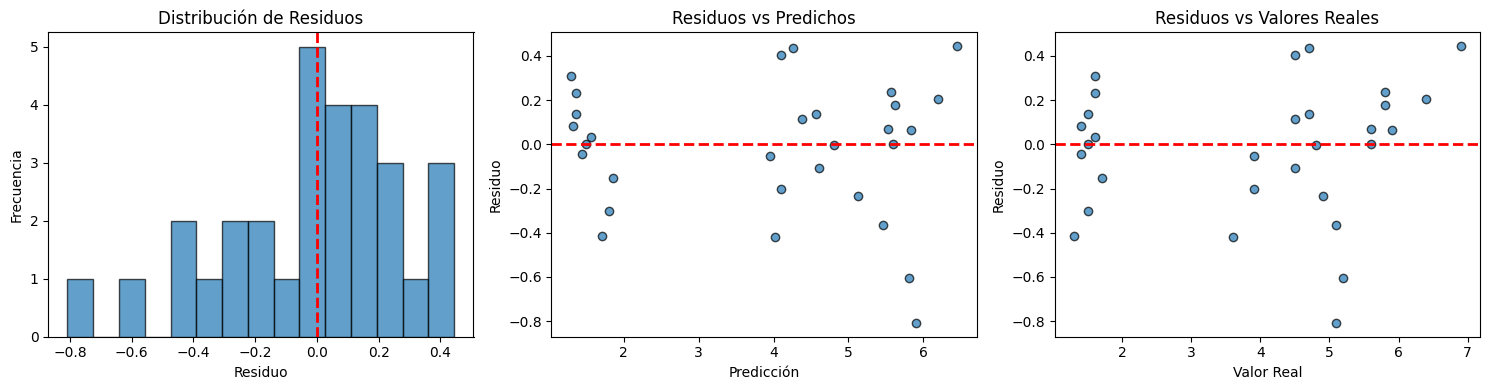

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma de residuos
axes[0].hist(residuos, bins=15, edgecolor="black", alpha=0.7)
axes[0].axvline(x=0, color="r", linestyle="--", linewidth=2)
axes[0].set_xlabel("Residuo")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de Residuos")

# Residuos vs Predichos
axes[1].scatter(mejor_pred, residuos, alpha=0.7, edgecolors="black")
axes[1].axhline(y=0, color="r", linestyle="--", linewidth=2)
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Residuo")
axes[1].set_title("Residuos vs Predichos")

# Residuos vs Valores Reales
axes[2].scatter(y_test, residuos, alpha=0.7, edgecolors="black")
axes[2].axhline(y=0, color="r", linestyle="--", linewidth=2)
axes[2].set_xlabel("Valor Real")
axes[2].set_ylabel("Residuo")
axes[2].set_title("Residuos vs Valores Reales")

plt.tight_layout()
plt.show()

## 12. Comparación visual de todos los modelos

Veamos cómo predicen todos los modelos en comparación con los valores reales.

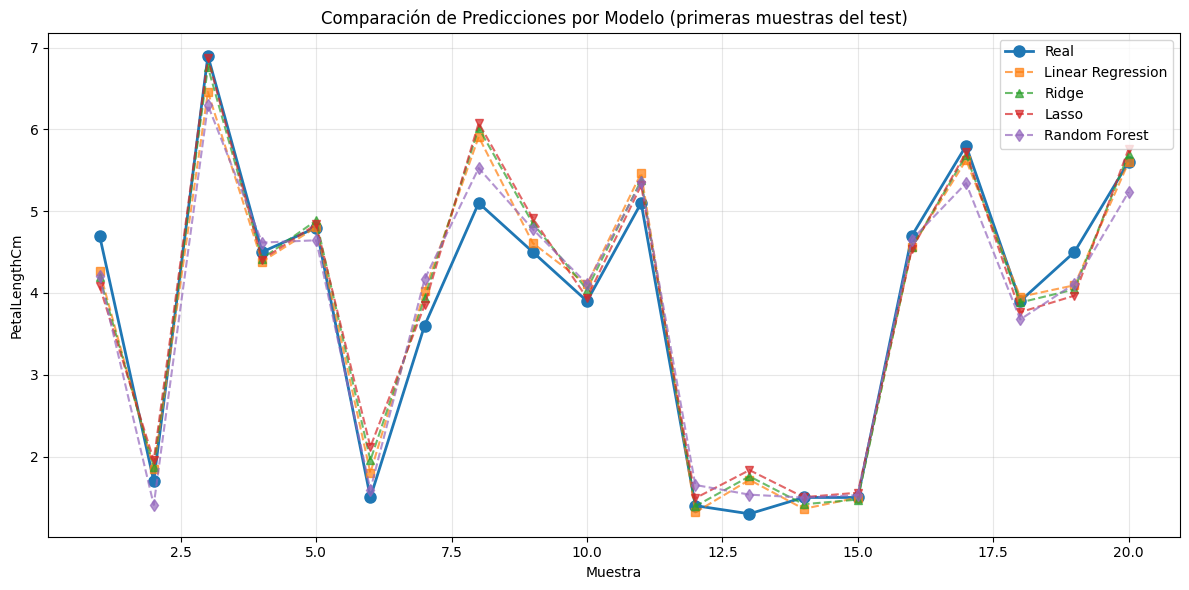

Primeras 10 predicciones vs reales:


,Real,Linear Regression,Ridge,Lasso,Random Forest
0,4.700,4.265,4.200,4.082,4.208
1,1.700,1.851,1.874,1.954,1.409
2,6.900,6.456,6.761,6.872,6.295
3,4.500,4.383,4.420,4.407,4.616
4,4.800,4.805,4.886,4.840,4.644
5,1.500,1.801,1.953,2.117,1.594
6,3.600,4.020,3.934,3.847,4.166
7,5.100,5.908,6.016,6.077,5.527
8,4.500,4.609,4.850,4.912,4.779
9,3.900,4.104,4.042,3.938,4.111


In [24]:
# Crear un DataFrame con todas las predicciones
df_predicciones = pd.DataFrame({
    "Real": y_test.values,
    "Linear Regression": pred_lr,
    "Ridge": pred_ridge,
    "Lasso": pred_lasso,
    "Random Forest": pred_rf
})

# Tomar solo una muestra para visualizar (primeros 20 puntos)
n_samples = min(20, len(y_test))

df_plot = df_predicciones.iloc[:n_samples].reset_index(drop=True)
df_plot.index += 1  # Empezar desde 1

# Gráfico
plt.figure(figsize=(12, 6))
plt.plot(df_plot.index, df_plot["Real"], "o-", label="Real", linewidth=2, markersize=8)
plt.plot(df_plot.index, df_plot["Linear Regression"], "s--", label="Linear Regression", alpha=0.7)
plt.plot(df_plot.index, df_plot["Ridge"], "^--", label="Ridge", alpha=0.7)
plt.plot(df_plot.index, df_plot["Lasso"], "v--", label="Lasso", alpha=0.7)
plt.plot(df_plot.index, df_plot["Random Forest"], "d--", label="Random Forest", alpha=0.7)

plt.xlabel("Muestra")
plt.ylabel("PetalLengthCm")
plt.title("Comparación de Predicciones por Modelo (primeras muestras del test)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Primeras 10 predicciones vs reales:")
df_predicciones.head(10)

## 13. Conclusiones

### Desempeño de los modelos:

1. **Random Forest** suele ser el modelo con mejor desempeño para este dataset, ya que puede capturar las relaciones no lineales entre las características y la longitud del pétalo.

2. **Ridge y Lasso** ofrecen un buen equilibrio entre simplicidad e interpretabilidad, con un rendimiento competitivo.

3. **Regresión Lineal** sirve como línea base. Si los datos tienen una relación lineal fuerte, su desempeño puede ser comparable a modelos más complejos.

### ¿Qué modelo seleccionar?

- Si priorizamos **precisión**: Random Forest (menor RMSE, mayor R²)
- Si priorizamos **interpretabilidad**: Regresión Lineal o Lasso (coeficientes claros)
- Si hay riesgo de **sobreajuste**: Ridge o Lasso (regularización)

### Hallazgos interesantes del dataset Iris:

- La longitud del pétalo (`PetalLengthCm`) está fuertemente correlacionada con el ancho del pétalo (`PetalWidthCm`).
- Las diferentes especies tienen rangos distintos de longitud de pétalo, lo que explica por qué incluir `Species` mejora el modelo.
- La especie *Iris-setosa* tiene pétalos notablemente más cortos que las otras dos especies.

## 14. Ejercicio integrador

1. Cambia el porcentaje de test a 30 % y compara resultados.
2. Modifica `max_depth` en Random Forest y observa el efecto en el sobreajuste.
3. Intenta predecir `SepalLengthCm` en lugar de `PetalLengthCm`. ¿Qué modelo funciona mejor?
4. Elimina la variable `Species` y compara el desempeño. ¿Cuánto empeora el modelo?
5. Añade interacciones entre variables (ej: `SepalLengthCm * PetalWidthCm`) y evalúa.

### Pregunta de cierre

¿Elegirías siempre el modelo con menor RMSE? Justifica tu respuesta considerando:
- Interpretabilidad
- Tiempo de inferencia
- Facilidad de despliegue
- Riesgo de sobreajuste

In [25]:
# Espacio para el ejercicio del alumnado
# Puedes empezar probando con un split diferente:

# X_train2, X_test2, y_train2, y_test2 = train_test_split(
#     X, y, test_size=0.3, random_state=42
# )
# print("Nuevo split - X_train:", X_train2.shape, "X_test:", X_test2.shape)